In [4]:
import sys
import os

# subir un nivel al proyecto raíz
PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

print("Ruta añadida:", PROJECT_ROOT)

Ruta añadida: /home/usuario_danna123/mineria-datos/pokemon-etl-project/07_jupyter_poke


In [5]:
import pandas as pd
from scripts.database import engine

with engine.connect() as conn:
    df = pd.read_sql("SELECT * FROM pokemon", conn)

df.head()

✅ Conexión engine lista


,id,name,height,weight,base_experience,types
0,1,bulbasaur,7,69,64,"grass, poison"
1,2,ivysaur,10,130,142,"grass, poison"
2,3,venusaur,20,1000,236,"grass, poison"
3,4,charmander,6,85,62,fire
4,5,charmeleon,11,190,142,fire


In [11]:
X = df[["height", "weight"]]
y = df["base_experience"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Intercepto:", model.intercept_)
print("Coeficientes:", model.coef_)

Intercepto: 12.609107470532734
Coeficientes: [11.47451032  0.03013188]


In [14]:
r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print("R2   :", r2)
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)

R2   : 0.9177295675984576
MAE  : 15.88363922852181
MSE  : 364.4580155388326
RMSE : 19.090783523439594


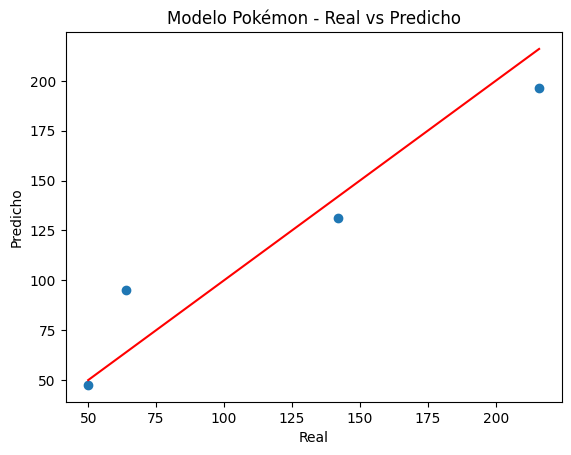

In [15]:
plt.scatter(y_test, pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Modelo Pokémon - Real vs Predicho")
plt.show()

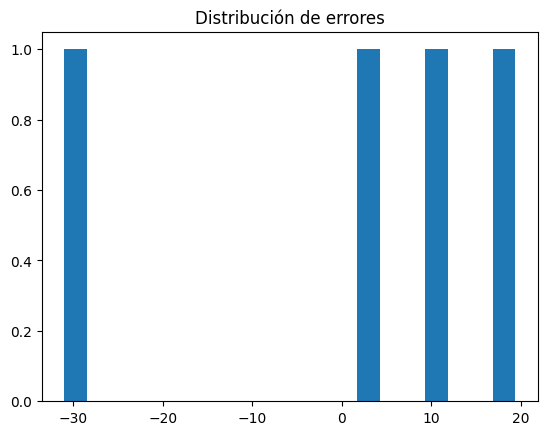

In [16]:
residuals = y_test - pred

plt.hist(residuals, bins=20)
plt.title("Distribución de errores")
plt.show()

In [17]:
X_ols = sm.add_constant(df[["height", "weight"]])
ols_model = sm.OLS(df["base_experience"], X_ols).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:        base_experience   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     73.93
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           4.10e-09
Time:                        20:57:27   Log-Likelihood:                -90.502
No. Observations:                  20   AIC:                             187.0
Df Residuals:                      17   BIC:                             190.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.7410     15.684      0.430      0.6